In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive')
os.chdir("gdrive/MyDrive/Manuscripts/Livingness")

Mounted at /content/gdrive


In [ ]:
from sklearn import linear_model

Interpreting ICCs

≥0.90: excellent; 0.75–0.90: good; 0.60–0.75: moderate.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# === CONFIG ===
csv_path = "data/scoring_final.csv"
image_col = "ImageName"
repeat_col = "RepeatIndex"

# Property columns exactly as in your file:
props = [
 "F1_LevelsOfScale","F2_StrongCenters","F3_Boundaries","F4_AlternatingRepetition",
 "F5_PositiveSpace","F6_GoodShape","F7_LocalSymmetries","F8_DeepInterlockAndAmbiguity",
 "F9_Contrast","F10_Gradients","F11_Roughness","F12_Echoes","F13_TheVoid",
 "F14_SimplicityAndInnerCalm","F15_Not-Separateness"
]

df = pd.read_csv(csv_path)

# --- Helper: ICC(2,1) and ICC(2,k) following Shrout & Fleiss (1979) absolute agreement ---
def icc2(df_mat):
    """
    df_mat: 2D numpy array shape (n_subjects, n_raters)
    Returns ICC(2,1), ICC(2,k), and ANOVA mean squares.
    """
    n, k = df_mat.shape
    means_subject = df_mat.mean(axis=1, keepdims=True)
    means_rater   = df_mat.mean(axis=0, keepdims=True)
    grand_mean    = df_mat.mean()

    ss_subject = k * ((means_subject - grand_mean)**2).sum()
    ss_rater   = n * ((means_rater   - grand_mean)**2).sum()
    ss_total   = ((df_mat - grand_mean)**2).sum()
    ss_error   = ss_total - ss_subject - ss_rater

    ms_subject = ss_subject / (n - 1)
    ms_rater   = ss_rater   / (k - 1)
    ms_error   = ss_error   / ((n - 1) * (k - 1))

    icc21 = (ms_subject - ms_error) / (ms_subject + (k - 1)*ms_error + (k*(ms_rater - ms_error))/n)
    icc2k = (ms_subject - ms_error) / (ms_subject + (ms_rater - ms_error)/n)
    return icc21, icc2k, (ms_subject, ms_rater, ms_error)

# --- Bootstrap CI for ICCs over subjects (images) ---
def bootstrap_icc(df_wide, B=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = df_wide.shape[0]
    icc21s, icc2ks = [], []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        m = df_wide.iloc[idx].to_numpy()
        ic21, ic2k, _ = icc2(m)
        icc21s.append(ic21)
        icc2ks.append(ic2k)
    low21, hi21 = np.nanpercentile(icc21s, [2.5, 97.5])
    low2k, hi2k = np.nanpercentile(icc2ks, [2.5, 97.5])
    return (low21, hi21), (low2k, hi2k)

# --- Per-property ICCs ---
summary_rows = []
for p in props:
    # make wide matrix: rows = images, cols = repeats
    pivot = df.pivot(index=image_col, columns=repeat_col, values=p).sort_index()
    ic21, ic2k, _ = icc2(pivot.to_numpy())
    ci21, ci2k = bootstrap_icc(pivot)
    summary_rows.append({
        "measure": p, "type": "property",
        "ICC2_1": ic21, "ICC2_1_CI_low": ci21[0], "ICC2_1_CI_high": ci21[1],
        "ICC2_k": ic2k, "ICC2_k_CI_low": ci2k[0], "ICC2_k_CI_high": ci2k[1]
    })

# --- Composite per run: mean of 15 properties ---
df["CompositeLivingness_Run"] = df[props].mean(axis=1)

# ICCs for the composite across repeats
pivot_comp = df.pivot(index=image_col, columns=repeat_col, values="CompositeLivingness_Run").sort_index()
ic21, ic2k, _ = icc2(pivot_comp.to_numpy())
ci21, ci2k = bootstrap_icc(pivot_comp)
summary_rows.append({
    "measure": "CompositeLivingness", "type": "composite",
    "ICC2_1": ic21, "ICC2_1_CI_low": ci21[0], "ICC2_1_CI_high": ci21[1],
    "ICC2_k": ic2k, "ICC2_k_CI_low": ci2k[0], "ICC2_k_CI_high": ci2k[1]
})

# --- Internal consistency (Cronbach's alpha) on run-averaged properties ---
img_prop = df.groupby(image_col)[props].mean()  # average across 10 runs
X = img_prop.to_numpy()
k = X.shape[1]
cov = np.cov(X, rowvar=False, ddof=1)
var_sum = np.trace(cov)
total_var = cov.sum()
alpha = (k / (k - 1.0)) * (1 - (var_sum / total_var))

alpha_row = {"measure":"CompositeLivingness", "type":"internal_consistency", "Cronbach_alpha": alpha}
summary_rows.append(alpha_row)

summary = pd.DataFrame(summary_rows)

# Save summary + export per-image final composite
summary_path = Path("livingness_reliability_summary.csv")
summary.to_csv(summary_path, index=False)

final_scores = img_prop.copy()
final_scores["CompositeLivingness_Final"] = final_scores.mean(axis=1)  # mean of 15 properties, averaged across runs
final_scores.to_csv("livingness_final_image_scores.csv")

print("Saved:", summary_path.resolve(), "and livingness_final_image_scores.csv")
print(summary.round(3))

Saved: /content/gdrive/MyDrive/Manuscripts/Livingness/livingness_reliability_summary.csv and livingness_final_image_scores.csv
                         measure                  type  ICC2_1  ICC2_1_CI_low  \
0               F1_LevelsOfScale              property   0.810          0.722   
1               F2_StrongCenters              property   0.747          0.655   
2                  F3_Boundaries              property   0.651          0.548   
3       F4_AlternatingRepetition              property   0.780          0.679   
4               F5_PositiveSpace              property   0.755          0.674   
5                   F6_GoodShape              property   0.781          0.712   
6             F7_LocalSymmetries              property   0.740          0.648   
7   F8_DeepInterlockAndAmbiguity              property   0.766          0.668   
8                    F9_Contrast              property   0.671          0.555   
9                  F10_Gradients              property   0.745 

### Livingness reliability & stability figures

Saved outputs in: /content/gdrive/MyDrive/Manuscripts/Livingness/livingness_outputs
 - FigureA_ICC_per_property.png
 - FigureB_BlandAltman_composite.png (if runs 0 & 1 exist)
 - FigureC_AI_vs_Human.png (if human ratings provided)
 - livingness_icc_per_property.csv
 - livingness_final_image_scores.csv


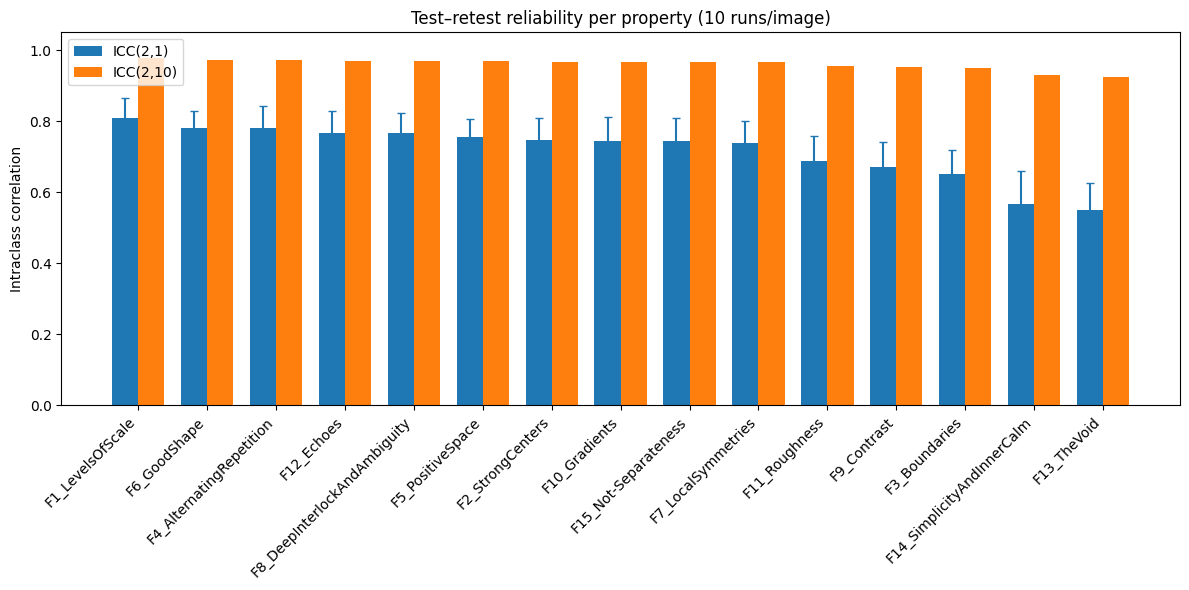

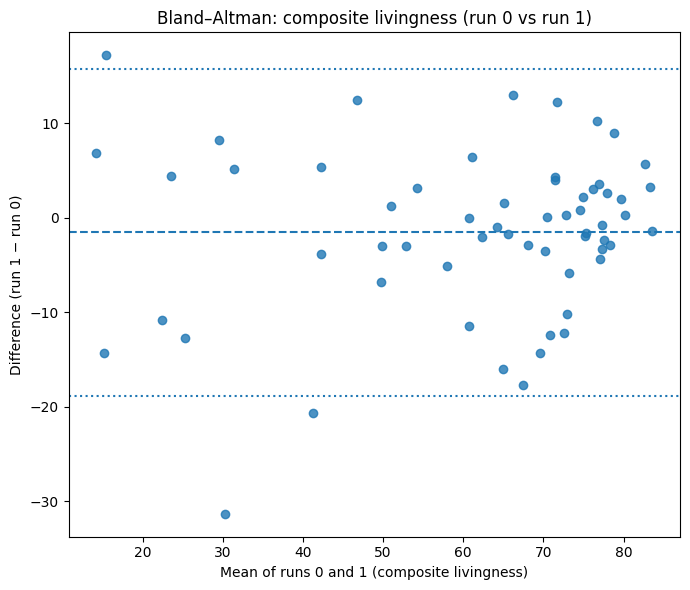

In [ ]:
# Requirements: pandas, numpy, matplotlib, scipy (for stats)
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------
# 1) CONFIG — EDIT THESE PATHS
# ------------------------------
CSV_PATH = "data/scoring_final.csv"  # your table with 10 repeats/image
IMAGE_ID_COL = "ImageName"             # or "ImageIdx" if you prefer
REPEAT_COL = "RepeatIndex"             # 0..9
# Optional: human ratings CSV with columns [ImageName, HumanLivingness]
HUMAN_RATINGS_CSV = None  # e.g., "human_livingness.csv" or leave as None

# Property columns (exact names you provided)
PROPS = [
 "F1_LevelsOfScale","F2_StrongCenters","F3_Boundaries","F4_AlternatingRepetition",
 "F5_PositiveSpace","F6_GoodShape","F7_LocalSymmetries","F8_DeepInterlockAndAmbiguity",
 "F9_Contrast","F10_Gradients","F11_Roughness","F12_Echoes","F13_TheVoid",
 "F14_SimplicityAndInnerCalm","F15_Not-Separateness"
]

OUTDIR = Path("livingness_outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)

# -----------------------------------------
# 2) HELPERS — ICC(2,1) / ICC(2,k) & CI
# -----------------------------------------
def icc2(mat):
    """
    ICC(2,1) and ICC(2,k) as per Shrout & Fleiss (1979), absolute agreement.
    mat: 2D array (n_subjects x n_raters)
    """
    mat = np.asarray(mat, float)
    n, k = mat.shape
    if n < 2 or k < 2:
        return np.nan, np.nan
    mpt = mat.mean()
    ms_subject = k * ((mat.mean(1) - mpt)**2).sum() / (n - 1)
    ms_rater   = n * ((mat.mean(0) - mpt)**2).sum() / (k - 1)
    ms_error   = ( (mat - mat.mean(1, keepdims=True) - mat.mean(0, keepdims=True) + mpt)**2 ).sum() / ((n - 1)*(k - 1))
    icc21 = (ms_subject - ms_error) / (ms_subject + (k - 1)*ms_error + (k*(ms_rater - ms_error))/n)
    icc2k = (ms_subject - ms_error) / (ms_subject + (ms_rater - ms_error)/n)
    return icc21, icc2k

def bootstrap_icc_ci(df_wide, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = df_wide.shape[0]
    ic21s, ic2ks = [], []
    arr = df_wide.to_numpy()
    for _ in range(B):
        idx = rng.integers(0, n, n)
        ic21, ic2k = icc2(arr[idx, :])
        ic21s.append(ic21); ic2ks.append(ic2k)
    low21, hi21 = np.nanpercentile(ic21s, [2.5, 97.5])
    low2k, hi2k = np.nanpercentile(ic2ks, [2.5, 97.5])
    return (low21, hi21), (low2k, hi2k)

def cronbach_alpha(X):
    """X: matrix (n_samples x n_items)"""
    X = np.asarray(X, float)
    k = X.shape[1]
    cov = np.cov(X, rowvar=False, ddof=1)
    var_sum = np.trace(cov)
    total_var = cov.sum()
    return (k / (k - 1.0)) * (1 - (var_sum / total_var))

# -----------------------------------------
# 3) LOAD & PREP
# -----------------------------------------
df = pd.read_csv(CSV_PATH)
# Composite per run: mean of 15 properties
df["CompositeLivingness_Run"] = df[PROPS].mean(axis=1)

# -----------------------------------------
# 4) FIGURE A — ICC per property (bars)
# -----------------------------------------
summary_rows = []
for p in PROPS:
    wide = df.pivot(index=IMAGE_ID_COL, columns=REPEAT_COL, values=p).sort_index()
    ic21, ic2k = icc2(wide.to_numpy())
    ci21, ci2k = bootstrap_icc_ci(wide)
    summary_rows.append({
        "measure": p,
        "ICC2_1": ic21, "ICC2_1_CI_low": ci21[0], "ICC2_1_CI_high": ci21[1],
        "ICC2_10": ic2k, "ICC2_10_CI_low": ci2k[0], "ICC2_10_CI_high": ci2k[1],
    })

summary_df = pd.DataFrame(summary_rows)
# Sort by ICC(2,1)
summary_df = summary_df.sort_values("ICC2_1", ascending=False).reset_index(drop=True)
summary_df.to_csv(OUTDIR / "livingness_icc_per_property.csv", index=False)

# Plot: two bar series (ICC2_1 with error bars, and ICC2_10)
labels = summary_df["measure"].tolist()
x = np.arange(len(labels))
width = 0.38

fig1, ax1 = plt.subplots(figsize=(12,6))
# Bars for ICC(2,1)
ax1.bar(x - width/2, summary_df["ICC2_1"].values, width, label="ICC(2,1)")
# Error bars for ICC(2,1)
err_low = summary_df["ICC2_1"].values - summary_df["ICC2_1_CI_low"].values
err_high = summary_df["ICC2_1_CI_high"].values - summary_df["ICC2_1"].values
ax1.errorbar(x - width/2, summary_df["ICC2_1"].values,
             yerr=[err_low, err_high], fmt='none', capsize=3)

# Bars for ICC(2,10)
ax1.bar(x + width/2, summary_df["ICC2_10"].values, width, label="ICC(2,10)")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Intraclass correlation")
ax1.set_title("Test–retest reliability per property (10 runs/image)")
ax1.legend(loc="upper left")
fig1.tight_layout()
fig1_path = OUTDIR / "FigureA_ICC_per_property.png"
fig1.savefig(fig1_path, dpi=300)

# -----------------------------------------
# 5) FIGURE B — Bland–Altman for composite
#    (Run 0 vs Run 1)
# -----------------------------------------
wide_comp = df.pivot(index=IMAGE_ID_COL, columns=REPEAT_COL, values="CompositeLivingness_Run").sort_index()
if 0 in wide_comp.columns and 1 in wide_comp.columns:
    a = wide_comp[0].values
    b = wide_comp[1].values
    avg = (a + b) / 2.0
    diff = b - a
    mean_diff = diff.mean()
    sd_diff = diff.std(ddof=1)

    fig2, ax2 = plt.subplots(figsize=(7,6))
    ax2.scatter(avg, diff, alpha=0.8)
    ax2.axhline(mean_diff, linestyle="--")                    # bias
    ax2.axhline(mean_diff + 1.96*sd_diff, linestyle=":")     # +1.96 SD
    ax2.axhline(mean_diff - 1.96*sd_diff, linestyle=":")     # -1.96 SD
    ax2.set_xlabel("Mean of runs 0 and 1 (composite livingness)")
    ax2.set_ylabel("Difference (run 1 − run 0)")
    ax2.set_title("Bland–Altman: composite livingness (run 0 vs run 1)")
    fig2.tight_layout()
    fig2_path = OUTDIR / "FigureB_BlandAltman_composite.png"
    fig2.savefig(fig2_path, dpi=300)

# -----------------------------------------
# 6) FIGURE C — Composite vs human ratings
# -----------------------------------------
if HUMAN_RATINGS_CSV:
    hr = pd.read_csv(HUMAN_RATINGS_CSV)
    # Expect columns: ImageName, HumanLivingness
    key = IMAGE_ID_COL
    hr = hr[[key, "HumanLivingness"]].dropna()
    # Final composite per image = mean across repeats
    comp_final = df.groupby(IMAGE_ID_COL)["CompositeLivingness_Run"].mean().reset_index()
    merged = pd.merge(comp_final, hr, on=key, how="inner")
    if len(merged) >= 3:
        r, p = stats.pearsonr(merged["CompositeLivingness_Run"], merged["HumanLivingness"])
        fig3, ax3 = plt.subplots(figsize=(7,6))
        ax3.scatter(merged["CompositeLivingness_Run"], merged["HumanLivingness"])
        # Least-squares fit line
        slope, intercept, *_ = stats.linregress(merged["CompositeLivingness_Run"], merged["HumanLivingness"])
        xx = np.linspace(merged["CompositeLivingness_Run"].min(), merged["CompositeLivingness_Run"].max(), 100)
        ax3.plot(xx, intercept + slope*xx)
        ax3.set_xlabel("AI composite livingness (mean of 15 properties, averaged over runs)")
        ax3.set_ylabel("Human livingness rating")
        ax3.set_title(f"Convergent validity: r = {r:.2f}, p = {p:.3g}")
        fig3.tight_layout()
        fig3_path = OUTDIR / "FigureC_AI_vs_Human.png"
        fig3.savefig(fig3_path, dpi=300)

# -----------------------------------------
# 7) SAVE composites per image (for your analyses)
# -----------------------------------------
final_props = df.groupby(IMAGE_ID_COL)[PROPS].mean()
final_props["CompositeLivingness_Final"] = final_props.mean(axis=1)
final_props.to_csv(OUTDIR / "livingness_final_image_scores.csv")

print("Saved outputs in:", OUTDIR.resolve())
print(" - FigureA_ICC_per_property.png")
print(" - FigureB_BlandAltman_composite.png (if runs 0 & 1 exist)")
print(" - FigureC_AI_vs_Human.png (if human ratings provided)")
print(" - livingness_icc_per_property.csv")
print(" - livingness_final_image_scores.csv")

Saved: livingness_outputs/FigureC_AI_vs_Human.png


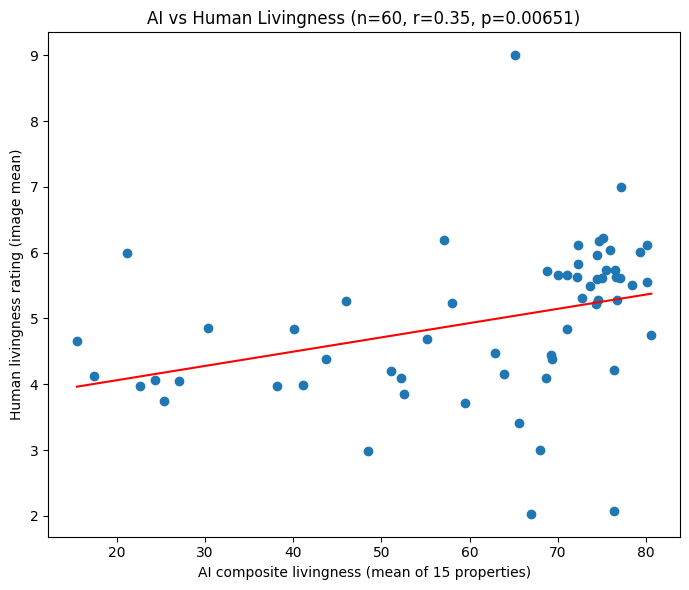

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Paths
human_means_path = "data/human_ratings_image_means.csv"
ai_scores_path = "data/scoring_final.csv"
out_path = "livingness_outputs/FigureC_AI_vs_Human.png"

# 15 property columns
PROPS = [
 "F1_LevelsOfScale","F2_StrongCenters","F3_Boundaries","F4_AlternatingRepetition",
 "F5_PositiveSpace","F6_GoodShape","F7_LocalSymmetries","F8_DeepInterlockAndAmbiguity",
 "F9_Contrast","F10_Gradients","F11_Roughness","F12_Echoes","F13_TheVoid",
 "F14_SimplicityAndInnerCalm","F15_Not-Separateness"
]

# Load human and AI
hum = pd.read_csv(human_means_path)
ai = pd.read_csv(ai_scores_path)

# Normalize image names (strip extensions if any)
hum["ImageName_clean"] = hum["ImageName"].astype(str).str.replace(r"\.JPG$|\.jpg$|\.png$", "", regex=True)
ai["ImageName_clean"]  = ai["ImageName"].astype(str).str.replace(r"\.JPG$|\.jpg$|\.png$", "", regex=True)

# AI composite: mean of 15 properties per run, then average across 10 runs per image
ai["Composite_Run"] = ai[PROPS].mean(axis=1)
ai_img = (
    ai.groupby("ImageName_clean")["Composite_Run"]
      .mean()
      .reset_index()
      .rename(columns={"Composite_Run": "CompositeLivingness_AI"})
)

# Merge
df = hum.merge(ai_img, on="ImageName_clean", how="inner")

# Keep images with human livingness
df = df.dropna(subset=["Livingness", "CompositeLivingness_AI"])

# Correlation
r, p = pearsonr(df["CompositeLivingness_AI"], df["Livingness"])

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(df["CompositeLivingness_AI"], df["Livingness"])

# Fit line
m, b = np.polyfit(df["CompositeLivingness_AI"], df["Livingness"], 1)
xx = np.linspace(df["CompositeLivingness_AI"].min(), df["CompositeLivingness_AI"].max(), 100)
plt.plot(xx, m*xx + b, color='red')

plt.xlabel("AI composite livingness (mean of 15 properties)")
plt.ylabel("Human livingness rating (image mean)")
plt.title(f"AI vs Human Livingness (n={len(df)}, r={r:.2f}, p={p:.3g})")
plt.tight_layout()
# plt.show()
plt.savefig(out_path, dpi=300)
# plt.close()
print("Saved:", out_path)

In [ ]:
# Fix ImageName mismatch (strip file extensions) and rerun validation
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Paths
ai_path = "data/scoring_final.csv"
human_path = "data/human_ratings_image_means.csv"
outdir = Path("livingness_outputs")
outdir.mkdir(exist_ok=True, parents=True)

# Load data
ai = pd.read_csv(ai_path)
hum = pd.read_csv(human_path)

# Normalize ImageName (remove extension if present)
ai["ImageName_clean"] = ai["ImageName"].str.replace(r"\.JPG$|\.jpg$|\.png$", "", regex=True)
hum["ImageName_clean"] = hum["ImageName"].str.replace(r"\.JPG$|\.jpg$|\.png$", "", regex=True)

# Define property columns
props = [
 "F1_LevelsOfScale","F2_StrongCenters","F3_Boundaries","F4_AlternatingRepetition",
 "F5_PositiveSpace","F6_GoodShape","F7_LocalSymmetries","F8_DeepInterlockAndAmbiguity",
 "F9_Contrast","F10_Gradients","F11_Roughness","F12_Echoes","F13_TheVoid",
 "F14_SimplicityAndInnerCalm","F15_Not-Separateness"
]

# Compute AI composite per run and per image
ai["Composite_Run"] = ai[props].mean(axis=1)
ai_img = (
    ai.groupby("ImageName_clean")["Composite_Run"]
    .mean()
    .reset_index()
    .rename(columns={"Composite_Run":"CompositeLivingness_AI"})
)

# Merge with human image-level ratings
df = hum.merge(ai_img, on="ImageName_clean", how="inner")
df = df.dropna(subset=["CompositeLivingness_AI","Livingness","Likability","Complexity"])

# Check sample size
n = len(df)

stats_out = {}
if n >= 2:
    stats_out["n_images"] = n
    stats_out["AI_vs_HumanLivingness_Pearson"] = pearsonr(df["CompositeLivingness_AI"], df["Livingness"])
    stats_out["AI_vs_HumanLivingness_Spearman"] = spearmanr(df["CompositeLivingness_AI"], df["Livingness"])
    stats_out["AI_vs_Likability_Pearson"] = pearsonr(df["CompositeLivingness_AI"], df["Likability"])
    stats_out["AI_vs_Complexity_Pearson"] = pearsonr(df["CompositeLivingness_AI"], df["Complexity"])

    # Partial regression
    X = sm.add_constant(df[["CompositeLivingness_AI","Likability","Complexity"]])
    y = df["Livingness"]
    model = sm.OLS(y, X).fit()

    with open(outdir / "partial_regression_summary.txt", "w") as f:
        f.write(model.summary().as_text())

    # # Scatter plot
    # plt.figure()
    # plt.scatter(df["CompositeLivingness_AI"], df["Livingness"])
    # m,b = np.polyfit(df["CompositeLivingness_AI"], df["Livingness"], 1)
    # xx = np.linspace(df["CompositeLivingness_AI"].min(), df["CompositeLivingness_AI"].max(), 100)
    # plt.plot(xx, m*xx+b)
    # r,p = stats_out["AI_vs_HumanLivingness_Pearson"]
    # plt.xlabel("AI composite livingness")
    # plt.ylabel("Human livingness (mean)")
    # plt.title(f"AI vs Human Livingness (n={n}, r={r:.2f}, p={p:.3g})")
    # plt.tight_layout()
    # plt.savefig(outdir / "Figure_AI_vs_Human_Livingness.png", dpi=300)
    # plt.close()

# Save outputs
df.to_csv(outdir / "merged_ai_human.csv", index=False)
pd.DataFrame(stats_out).to_csv(outdir / "correlation_stats.csv", index=False)

stats_out, df.head()


({'n_images': 60,
  'AI_vs_HumanLivingness_Pearson': PearsonRResult(statistic=np.float64(0.3475268789496289), pvalue=np.float64(0.006514974691990546)),
  'AI_vs_HumanLivingness_Spearman': SignificanceResult(statistic=np.float64(0.5211060214260113), pvalue=np.float64(1.9648440471243266e-05)),
  'AI_vs_Likability_Pearson': PearsonRResult(statistic=np.float64(0.459154141746679), pvalue=np.float64(0.00022417270584687812)),
  'AI_vs_Complexity_Pearson': PearsonRResult(statistic=np.float64(0.7343587590773109), pvalue=np.float64(2.4325389273611606e-11))},
   ImageName  Complexity  Likability  Livingness ImageName_clean  \
 0      A10a    5.222222    4.984127    5.507937            A10a   
 1      A10b    4.920635    4.761905    2.031746            A10b   
 2       A1a    5.730159    6.031746    5.619048             A1a   
 3       A1b    3.841270    5.492063    5.222222             A1b   
 4       A2a    5.031746    5.809524    5.730159             A2a   
 
    CompositeLivingness_AI  
 0    